In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
sdss_path = '/global/cfs/cdirs/desi/target/analysis/truth/parent/sdss-specObj-dr16-unique-trimmed.fits'
eboss_path = '/global/cfs/cdirs/desi/target/analysis/truth/parent/eBOSS_LRG_full_ALLdata-vDR16.fits'

In [4]:
survey = Table(fitsio.read(sdss_path, columns=['SURVEY']))
t = Table()
t['SURVEY'], t['count'] = np.unique(survey['SURVEY'], return_counts=True)
t.sort('count')
t

SURVEY,count
str6,int64
segue2,120712
segue1,238631
eboss,1218413
sdss,1230784
boss,2298505


## SDSS

In [5]:
idx = np.where(survey['SURVEY']=='sdss  ')
sdss = Table(fitsio.read(sdss_path, rows=idx))
print(len(sdss))

1230784


In [6]:
mask = sdss['LEGACY_TARGET1'] & 2**5>0  # GALAXY_RED, i.e., SDSS LRGs
print('LEGACY_TARGET1', np.sum(mask), np.sum(mask)/len(mask))
sdss = sdss[mask]
print(len(sdss))

LEGACY_TARGET1 194839 0.1583047878425459
194839


In [7]:
mask = sdss['SPECPRIMARY']==1
print('SPECPRIMARY', np.sum(mask), np.sum(mask)/len(mask))

mask &= (sdss['ZWARNING']==0)
print('ZWARNING', np.sum(mask), np.sum(mask)/len(mask))

mask &= sdss['PLATEQUALITY']!='bad     '
print('PLATEQUALITY', np.sum(mask), np.sum(mask)/len(mask))

sdss = sdss[mask]
print(len(sdss))

SPECPRIMARY 194839 1.0
ZWARNING 193988 0.9956322912763872
PLATEQUALITY 193187 0.9915212046869467
193187


In [8]:
t = Table()
t['CLASS'], t['count'] = np.unique(sdss['CLASS'], return_counts=True)
t['frac (%)'] = t['count']/len(sdss)*100
# t['type'], t['count'] = np.unique(sdss['TYPE'][mask], return_counts=True)
# t['frac (%)'] = t['count']/np.sum(mask)*100
t['frac (%)'].format = '%.1f'
t.sort('count')
# t.pprint_all()
t

CLASS,count,frac (%)
str6,int64,float64
QSO,468,0.2
STAR,3307,1.7
GALAXY,189412,98.0


In [9]:
mask = (sdss['CLASS']=='GALAXY')
print('CLASS', np.sum(mask), np.sum(mask)/len(mask))

mask &= (sdss['Z'] > 0.0003)
print('Z', np.sum(mask), np.sum(mask)/len(mask))

sdss = sdss[mask]
print(len(sdss))

CLASS 189412 0.980459347678674
Z 189367 0.9802264127503404
189367


## BOSS

In [10]:
idx = np.where(survey['SURVEY']=='boss  ')
boss = Table(fitsio.read(sdss_path, rows=idx))
print(len(boss))

2298505


In [11]:
# Select BOSS LRGs
mask = np.zeros(len(boss), dtype=bool)
bits_to_keep = [0, 1, 2, 3]
for bit in bits_to_keep:
    mask = mask | (boss['BOSS_TARGET1'] & (2**bit) > 0)
print('BOSS_TARGET1', np.sum(mask), np.sum(mask)/len(mask))
boss = boss[mask]
print(len(boss))

BOSS_TARGET1 1364481 0.5936384737035595
1364481


In [12]:
mask = boss['SPECPRIMARY']==1
print('SPECPRIMARY', np.sum(mask), np.sum(mask)/len(mask))

mask &= (boss['ZWARNING_NOQSO']==0)
print('ZWARNING', np.sum(mask), np.sum(mask)/len(mask))

mask &= boss['PLATEQUALITY']!='bad     '
print('PLATEQUALITY', np.sum(mask), np.sum(mask)/len(mask))

boss = boss[mask]
print(len(boss))

SPECPRIMARY 1364481 1.0
ZWARNING 1341481 0.9831437740796684
PLATEQUALITY 1341481 0.9831437740796684
1341481


In [13]:
t = Table()
t['CLASS'], t['count'] = np.unique(sdss['CLASS'], return_counts=True)
t['frac (%)'] = t['count']/len(sdss)*100
# t['type'], t['count'] = np.unique(sdss['TYPE'][mask], return_counts=True)
# t['frac (%)'] = t['count']/np.sum(mask)*100
t['frac (%)'].format = '%.1f'
t.sort('count')
# t.pprint_all()
t

CLASS,count,frac (%)
str6,int64,float64
GALAXY,189367,100.0


In [14]:
mask = (boss['CLASS_NOQSO']=='GALAXY')
print('CLASS_NOQSO', np.sum(mask), np.sum(mask)/len(mask))

mask &= (boss['Z_NOQSO'] > 0.0003)
print('Z_NOQSO', np.sum(mask), np.sum(mask)/len(mask))

boss = boss[mask]
print(len(boss))

CLASS_NOQSO 1312030 0.9780459059800325
Z_NOQSO 1311810 0.9778819081298953
1311810


## eBOSS

In [15]:
eboss = Table(fitsio.read(eboss_path))

In [16]:
mask = eboss['IMATCH']==1
print('IMATCH', np.sum(mask), np.sum(mask)/len(mask))
mask &= (eboss['Z']>0.002) & (eboss['Z']<1.3)
print('Z', np.sum(mask), np.sum(mask)/len(mask))
eboss = eboss[mask]
print(len(eboss))

IMATCH 209894 0.6730650829891486
Z 209572 0.6720325286678125
209572


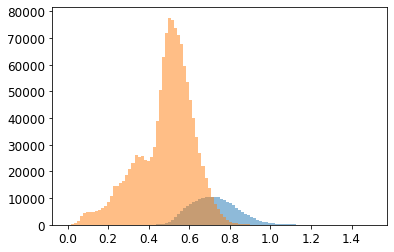

In [18]:
plt.hist(eboss['Z'], 100, range=(0, 1.5), alpha=0.5)
plt.hist(boss['Z_NOQSO'], 100, range=(0, 1.5), alpha=0.5)
plt.show()

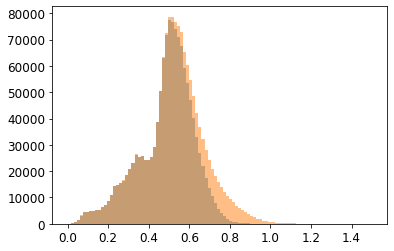

In [29]:
# plt.hist(, 100, range=(0, 1.5), alpha=0.5)
plt.hist(boss['Z_NOQSO'], 100, range=(0, 1.5), alpha=0.5)
plt.hist(np.concatenate([eboss['Z'], boss['Z_NOQSO']]), 100, range=(0, 1.5), alpha=0.5)
plt.show()

In [19]:
sdss = sdss[['Z']]
sdss['survey'] = 'sdss'
boss = boss[['Z_NOQSO']]
boss.rename_column('Z_NOQSO', 'Z')
boss['survey'] = 'boss'
eboss = eboss[['Z']]
eboss['survey'] = 'eboss'

cat = vstack([sdss, boss, eboss])
cat.write('/global/cfs/cdirs/desi/users/rongpu/data/lrg/sdss_boss_eboss_lrgs.fits')

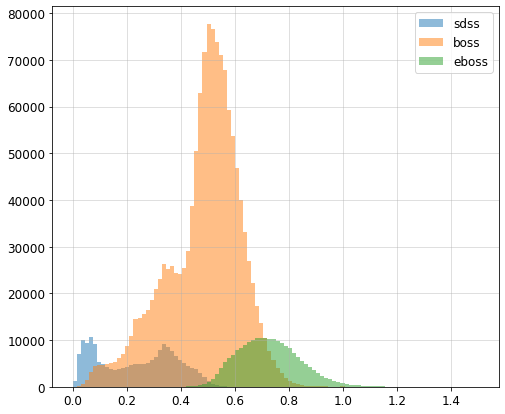

In [25]:
plt.figure(figsize=(8, 7))
for survey in ['sdss', 'boss', 'eboss']:
    mask = cat['survey']==survey
    plt.hist(cat['Z'][mask], 100, range=(0, 1.5), alpha=0.5, label=survey)
plt.grid(alpha=0.5)
plt.legend()
plt.show()

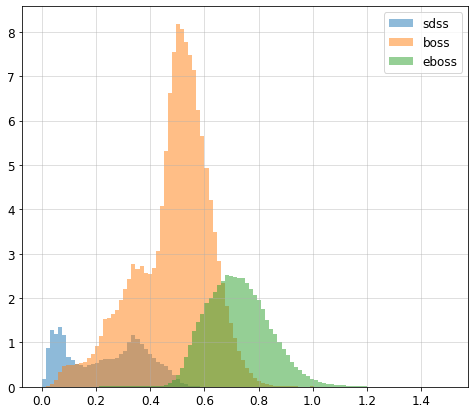

In [28]:
# Normalize by area
areas = {'sdss':7900, 'boss':9500, 'eboss':4200}
plt.figure(figsize=(8, 7))
for survey in ['sdss', 'boss', 'eboss']:
    mask = cat['survey']==survey
    plt.hist(cat['Z'][mask], 100, range=(0, 1.5), alpha=0.5, label=survey,
            weights=np.full(np.sum(mask), 1/areas[survey]))
plt.grid(alpha=0.5)
plt.legend()
plt.show()